# Explore test_config Pipeline Results

Load and analyze results from `test_config.py` runs. Compare correlations across configurations and evaluate the effect of excluding problematic topics (same exclusions as `run_gss_pca.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
import glob

RESULTS_DIR = Path('../results')

# Excluded topics (same as run_gss_pca.py defaults)
EXCLUDE_PUBLIC = ['hubbywk1', 'racdif1', 'racdif2', 'racdif3', 'racdif4',
                  'workwhts', 'wlthwhts', 'intlwhts']
EXCLUDE_PRIVATE = ['reborn', 'marwht', 'helpful', 'helpfulnv', 'helpfulv']

## 1. Load All Results

In [2]:
# Load all final detail pickles (exclude checkpoints and per-category files)
pkl_files = sorted(RESULTS_DIR.glob('test_config_detail_*_20*.pkl'))
pkl_files = [f for f in pkl_files if 'checkpoint' not in f.name
             and 'public_issues' not in f.name
             and 'private_life' not in f.name]

print(f'Found {len(pkl_files)} result files:')
for f in pkl_files:
    print(f'  {f.name}')

Found 5 result files:
  test_config_detail_Llama-3.1-8B-Instruct_20260206_171739.pkl
  test_config_detail_all_A_gemma-2-9b-it_20260208_213213.pkl
  test_config_detail_all_B_gemma-2-9b-it_20260208_203953.pkl
  test_config_detail_all_B_lifestyle_gemma-2-9b-it_20260208_230901.pkl
  test_config_detail_core_B_gemma-2-9b-it_20260208_170812.pkl


In [3]:
# Load each result file into a dict
results = {}
for f in pkl_files:
    # Parse tag from filename: test_config_detail_{tag}_{model}_{timestamp}.pkl
    name = f.stem  # without .pkl
    df = pd.read_pickle(f)
    results[name] = df
    print(f'{name}: {len(df)} topics ({df["category"].value_counts().to_dict()})')

test_config_detail_Llama-3.1-8B-Instruct_20260206_171739: 209 topics ({'public_issues': 134, 'private_life': 75})
test_config_detail_all_A_gemma-2-9b-it_20260208_213213: 209 topics ({'public_issues': 134, 'private_life': 75})
test_config_detail_all_B_gemma-2-9b-it_20260208_203953: 209 topics ({'public_issues': 134, 'private_life': 75})
test_config_detail_all_B_lifestyle_gemma-2-9b-it_20260208_230901: 209 topics ({'public_issues': 134, 'private_life': 75})
test_config_detail_core_B_gemma-2-9b-it_20260208_170812: 209 topics ({'public_issues': 134, 'private_life': 75})


## 2. Load Survey Polarization Data

In [4]:
pol_pub = pd.read_csv('../../data/polarization/public_issues_polarization.csv')
pol_priv = pd.read_csv('../../data/polarization/private_life_polarization.csv')

print(f'Public issues: {len(pol_pub)} topics')
print(f'Private life:  {len(pol_priv)} topics')

Public issues: 134 topics
Private life:  88 topics


## 3. Correlation Analysis: All Topics vs Excluded Topics

Compare correlations with and without the excluded topics from `run_gss_pca.py`.

In [5]:
def compute_correlations(df_detail, pol_pub, pol_priv,
                         exclude_public=None, exclude_private=None):
    """Compute Pearson and Spearman correlations for each category."""
    pol_data = {'public_issues': pol_pub, 'private_life': pol_priv}
    exclude_map = {
        'public_issues': set(exclude_public or []),
        'private_life': set(exclude_private or []),
    }
    
    rows = []
    for cat_name in ['public_issues', 'private_life']:
        df_cat = df_detail[df_detail['category'] == cat_name].copy()
        if len(df_cat) == 0:
            continue
        
        # Apply exclusions
        excl = exclude_map[cat_name]
        if excl:
            df_cat = df_cat[~df_cat['Topic'].isin(excl)]
        
        df_pol = pol_data[cat_name]
        if excl:
            df_pol = df_pol[~df_pol['variable'].isin(excl)]
        
        df_merged = df_cat.merge(
            df_pol[['variable', 'polarization']].rename(
                columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
            ),
            on='Topic', how='inner'
        )
        
        for method in ['mean', 'median']:
            suffix = '' if method == 'mean' else '_median'
            col = f'Avg_Mahal_PCA15{suffix}'
            if col not in df_merged.columns:
                continue
            
            r, r_p = pearsonr(df_merged[col], df_merged['GSS_Polarization'])
            rho, rho_p = spearmanr(df_merged[col], df_merged['GSS_Polarization'])
            rows.append({
                'category': cat_name,
                'centroid': method,
                'n_topics': len(df_merged),
                'r': round(r, 4),
                'r_pval': round(r_p, 4),
                'rho': round(rho, 4),
                'rho_pval': round(rho_p, 4),
            })
    
    return pd.DataFrame(rows)

In [6]:
# Compare: all topics vs excluded topics, for each result file
for name, df_detail in results.items():
    print(f'\n{"="*80}')
    print(f'{name}')
    print(f'{"="*80}')
    
    print('\n--- All topics ---')
    df_all = compute_correlations(df_detail, pol_pub, pol_priv)
    print(df_all.to_string(index=False))
    
    print('\n--- After excluding problematic topics ---')
    print(f'    Excluded public:  {EXCLUDE_PUBLIC}')
    print(f'    Excluded private: {EXCLUDE_PRIVATE}')
    df_excl = compute_correlations(df_detail, pol_pub, pol_priv,
                                   exclude_public=EXCLUDE_PUBLIC,
                                   exclude_private=EXCLUDE_PRIVATE)
    print(df_excl.to_string(index=False))
    
    # Show improvement
    if len(df_all) > 0 and len(df_excl) > 0:
        print('\n--- Improvement (excluded - all) ---')
        merged = df_all.merge(df_excl, on=['category', 'centroid'], suffixes=('_all', '_excl'))
        merged['delta_r'] = merged['r_excl'] - merged['r_all']
        merged['delta_rho'] = merged['rho_excl'] - merged['rho_all']
        print(merged[['category', 'centroid', 'n_topics_all', 'n_topics_excl',
                       'r_all', 'r_excl', 'delta_r', 'rho_all', 'rho_excl', 'delta_rho']].to_string(index=False))


test_config_detail_Llama-3.1-8B-Instruct_20260206_171739

--- All topics ---
     category centroid  n_topics      r  r_pval    rho  rho_pval
public_issues     mean       134 0.2045  0.0178 0.2313    0.0072
public_issues   median       134 0.2624  0.0022 0.2904    0.0007
 private_life     mean        75 0.4461  0.0001 0.4425    0.0001
 private_life   median        75 0.4569  0.0000 0.4496    0.0001

--- After excluding problematic topics ---
    Excluded public:  ['hubbywk1', 'racdif1', 'racdif2', 'racdif3', 'racdif4', 'workwhts', 'wlthwhts', 'intlwhts']
    Excluded private: ['reborn', 'marwht', 'helpful', 'helpfulnv', 'helpfulv']
     category centroid  n_topics      r  r_pval    rho  rho_pval
public_issues     mean       126 0.1955  0.0282 0.2249    0.0113
public_issues   median       126 0.2614  0.0031 0.2891    0.0010
 private_life     mean        72 0.4599  0.0000 0.4549    0.0001
 private_life   median        72 0.4597  0.0000 0.4499    0.0001

--- Improvement (excluded - all) 

## 4. Summary Table Across All Configurations

In [7]:
# Build a summary table: one row per (run, category, centroid), with both all/excluded correlations
summary_rows = []
for name, df_detail in results.items():
    df_all = compute_correlations(df_detail, pol_pub, pol_priv)
    df_excl = compute_correlations(df_detail, pol_pub, pol_priv,
                                   exclude_public=EXCLUDE_PUBLIC,
                                   exclude_private=EXCLUDE_PRIVATE)
    
    for _, row_all in df_all.iterrows():
        row_excl = df_excl[(df_excl['category'] == row_all['category']) &
                           (df_excl['centroid'] == row_all['centroid'])]
        entry = {
            'run': name.replace('test_config_detail_', ''),
            'category': row_all['category'],
            'centroid': row_all['centroid'],
            'n_all': row_all['n_topics'],
            'r_all': row_all['r'],
            'rho_all': row_all['rho'],
        }
        if len(row_excl) > 0:
            row_excl = row_excl.iloc[0]
            entry['n_excl'] = row_excl['n_topics']
            entry['r_excl'] = row_excl['r']
            entry['rho_excl'] = row_excl['rho']
        summary_rows.append(entry)

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

                                          run      category centroid  n_all   r_all  rho_all  n_excl  r_excl  rho_excl
        Llama-3.1-8B-Instruct_20260206_171739 public_issues     mean    134  0.2045   0.2313     126  0.1955    0.2249
        Llama-3.1-8B-Instruct_20260206_171739 public_issues   median    134  0.2624   0.2904     126  0.2614    0.2891
        Llama-3.1-8B-Instruct_20260206_171739  private_life     mean     75  0.4461   0.4425      72  0.4599    0.4549
        Llama-3.1-8B-Instruct_20260206_171739  private_life   median     75  0.4569   0.4496      72  0.4597    0.4499
          all_A_gemma-2-9b-it_20260208_213213 public_issues     mean    134  0.1843   0.1766     126  0.1519    0.1427
          all_A_gemma-2-9b-it_20260208_213213 public_issues   median    134  0.0634   0.1375     126  0.0595    0.1233
          all_A_gemma-2-9b-it_20260208_213213  private_life     mean     75  0.3690   0.3274      72  0.3919    0.3679
          all_A_gemma-2-9b-it_20260208_213213  p

## 5. Scatter Plots: LLM Polarization vs Survey Polarization

In [8]:
def plot_scatter(df_detail, pol_pub, pol_priv, title,
                 exclude_public=None, exclude_private=None, method='mean'):
    """Scatter plot of LLM polarization vs GSS polarization."""
    suffix = '' if method == 'mean' else '_median'
    col = f'Avg_Mahal_PCA15{suffix}'
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (cat_name, df_pol) in zip(axes, [('public_issues', pol_pub), ('private_life', pol_priv)]):
        df_cat = df_detail[df_detail['category'] == cat_name].copy()
        excl = set((exclude_public if cat_name == 'public_issues' else exclude_private) or [])
        
        df_merged = df_cat.merge(
            df_pol[['variable', 'polarization']].rename(
                columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
            ),
            on='Topic', how='inner'
        )
        
        # Plot excluded topics in a different color
        mask_excl = df_merged['Topic'].isin(excl)
        df_keep = df_merged[~mask_excl]
        df_drop = df_merged[mask_excl]
        
        ax.scatter(df_keep['GSS_Polarization'], df_keep[col],
                   alpha=0.6, s=30, label='Included')
        if len(df_drop) > 0:
            ax.scatter(df_drop['GSS_Polarization'], df_drop[col],
                       alpha=0.6, s=30, color='red', marker='x', label='Excluded')
            for _, row in df_drop.iterrows():
                ax.annotate(row['Topic'], (row['GSS_Polarization'], row[col]),
                            fontsize=7, alpha=0.7)
        
        # Correlation for included topics only
        r, _ = pearsonr(df_keep[col], df_keep['GSS_Polarization'])
        rho, _ = spearmanr(df_keep[col], df_keep['GSS_Polarization'])
        
        ax.set_xlabel('GSS Survey Polarization')
        ax.set_ylabel(f'LLM Mahalanobis PCA-15 ({method})')
        ax.set_title(f'{cat_name} (n={len(df_keep)}, r={r:.3f}, rho={rho:.3f})')
        ax.legend(fontsize=8)
    
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

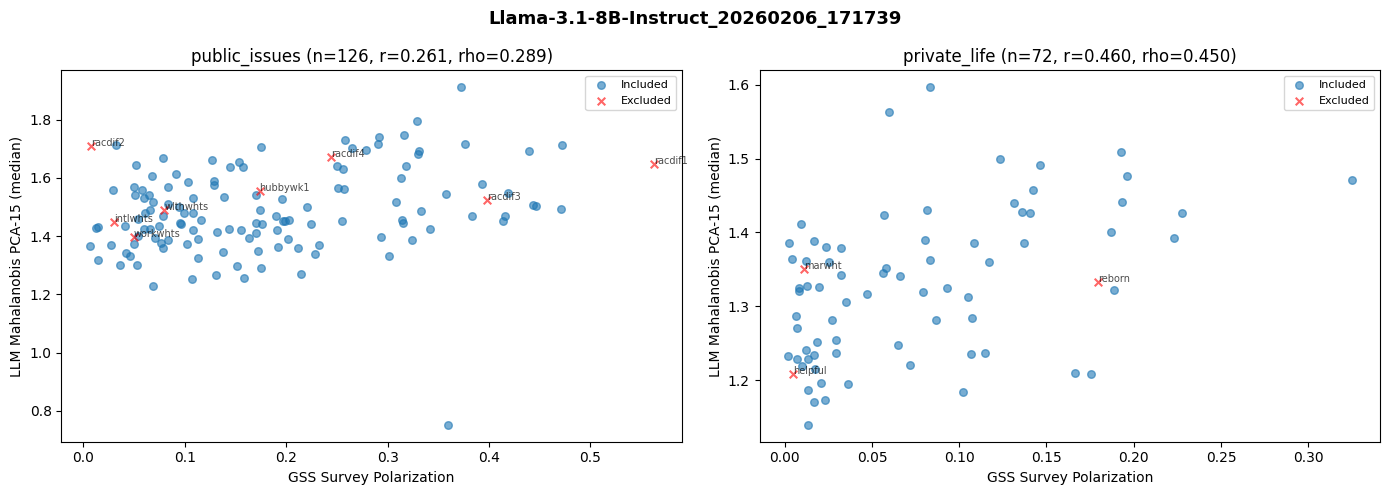

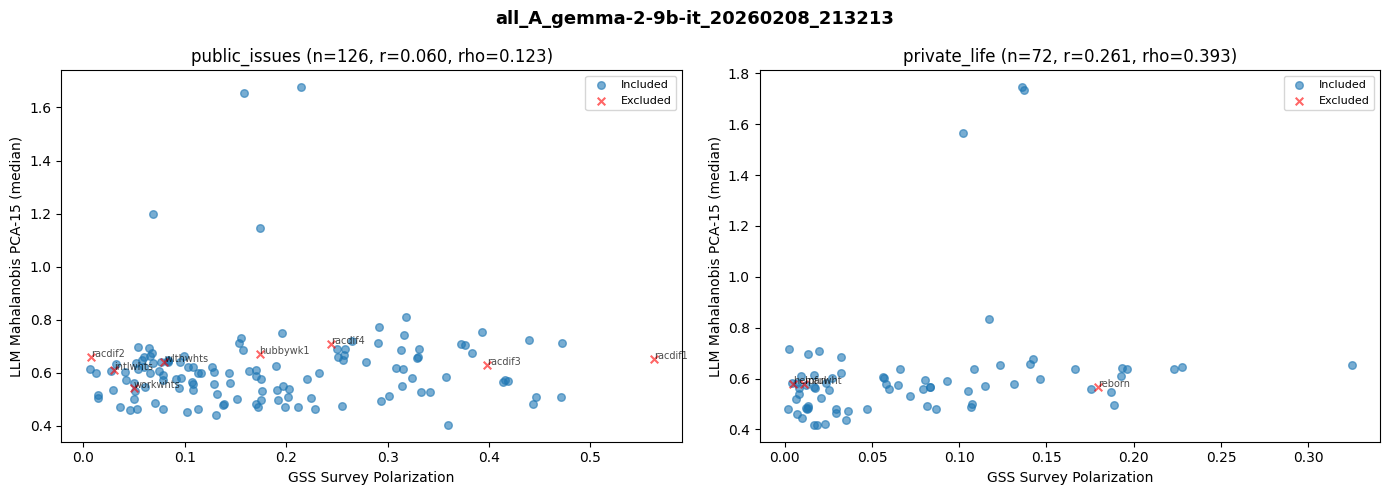

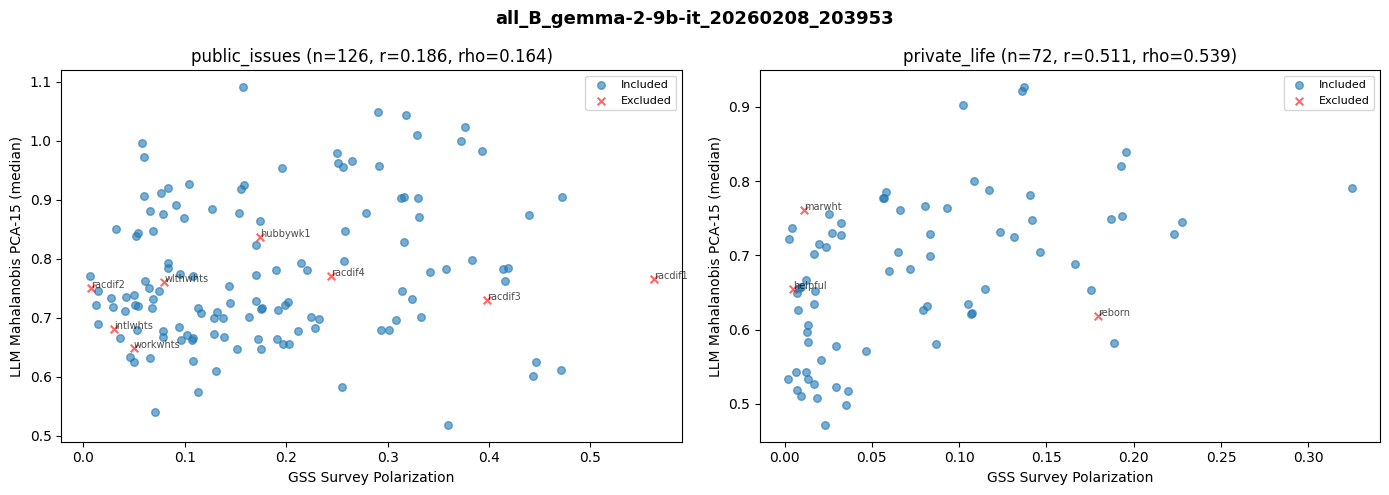

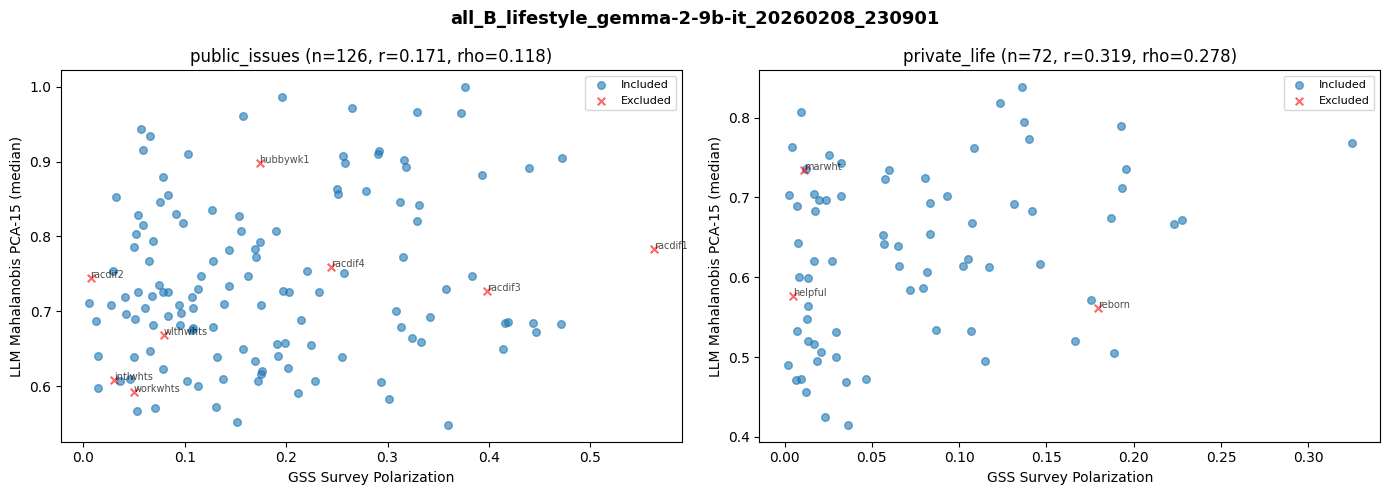

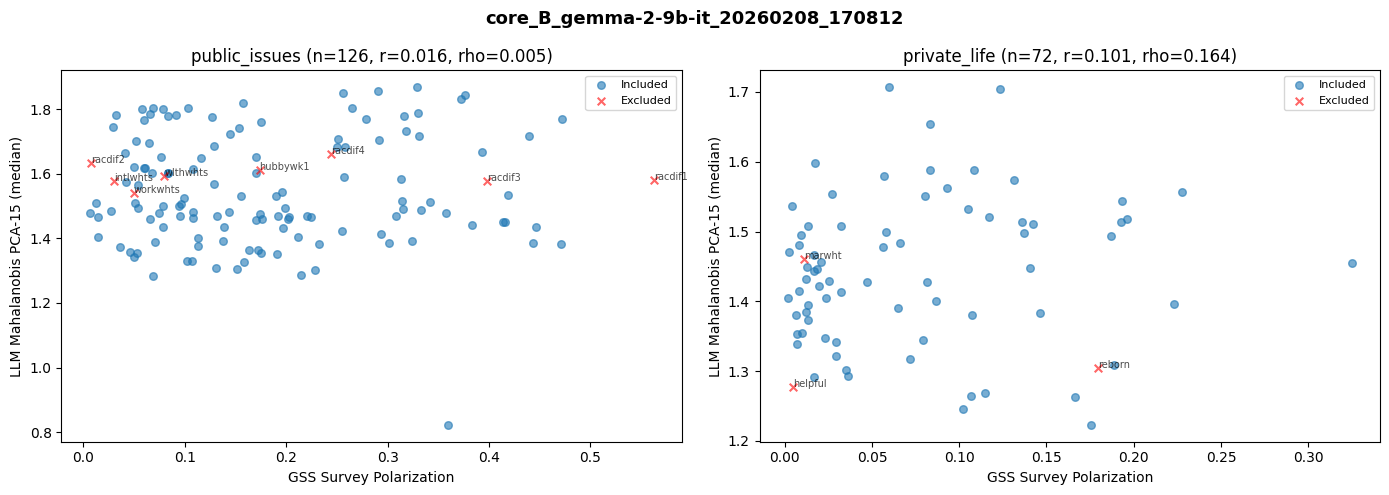

In [9]:
# Plot for each result file (using median centroid)
for name, df_detail in results.items():
    short_name = name.replace('test_config_detail_', '')
    plot_scatter(df_detail, pol_pub, pol_priv,
                 title=short_name,
                 exclude_public=EXCLUDE_PUBLIC,
                 exclude_private=EXCLUDE_PRIVATE,
                 method='median')

## 6. Which Excluded Topics Are Outliers?

Check whether the excluded topics systematically pull the correlation up or down.

In [10]:
# For the best run, show how each excluded topic compares
# Use the all_B_gemma run as the primary example
primary_key = [k for k in results.keys() if 'all_B_gemma' in k and 'lifestyle' not in k]
if primary_key:
    df_detail = results[primary_key[0]]
    print(f'Using: {primary_key[0]}')
    
    for cat_name, excl_list, df_pol in [
        ('public_issues', EXCLUDE_PUBLIC, pol_pub),
        ('private_life', EXCLUDE_PRIVATE, pol_priv),
    ]:
        df_cat = df_detail[df_detail['category'] == cat_name]
        df_merged = df_cat.merge(
            df_pol[['variable', 'polarization']].rename(
                columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
            ),
            on='Topic', how='inner'
        )
        
        print(f'\n--- {cat_name} excluded topics ---')
        excl_rows = df_merged[df_merged['Topic'].isin(excl_list)]
        if len(excl_rows) > 0:
            print(excl_rows[['Topic', 'GSS_Polarization', 'Avg_Mahal_PCA15',
                             'Avg_Mahal_PCA15_median']].to_string(index=False))
        else:
            print('  (none of the excluded topics found in results)')

Using: test_config_detail_all_B_gemma-2-9b-it_20260208_203953

--- public_issues excluded topics ---
   Topic  GSS_Polarization  Avg_Mahal_PCA15  Avg_Mahal_PCA15_median
hubbywk1          0.173802         0.935337                0.837361
 racdif1          0.562443         0.870807                0.766209
 racdif2          0.007130         0.850025                0.750311
 racdif3          0.398273         0.816085                0.730332
 racdif4          0.244230         0.856826                0.771269
intlwhts          0.030388         0.664990                0.681636
wlthwhts          0.079591         0.738933                0.761087
workwhts          0.049741         0.645851                0.649345

--- private_life excluded topics ---
  Topic  GSS_Polarization  Avg_Mahal_PCA15  Avg_Mahal_PCA15_median
 reborn          0.179415         0.656953                0.618486
helpful          0.004686         0.719958                0.654916
 marwht          0.010984         0.840262      

## 7. Per-Topic Results Table

In [11]:
# Show full per-topic results for the primary run, merged with survey polarization
if primary_key:
    df_detail = results[primary_key[0]]
    
    for cat_name, df_pol in [('public_issues', pol_pub), ('private_life', pol_priv)]:
        df_cat = df_detail[df_detail['category'] == cat_name]
        df_merged = df_cat.merge(
            df_pol[['variable', 'polarization', 'area']].rename(
                columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
            ),
            on='Topic', how='inner'
        ).sort_values('GSS_Polarization', ascending=False)
        
        print(f'\n{"="*80}')
        print(f'{cat_name.upper()} ({len(df_merged)} topics)')
        print(f'{"="*80}')
        print(df_merged[['Topic', 'area', 'GSS_Polarization',
                         'Avg_Mahal_PCA15', 'Avg_Mahal_PCA15_median',
                         'n_sampled', 'n_dem', 'n_rep']].to_string(index=False))


PUBLIC_ISSUES (134 topics)
    Topic                                           area  GSS_Polarization  Avg_Mahal_PCA15  Avg_Mahal_PCA15_median  n_sampled  n_dem  n_rep
  racdif1              Race: Explanations for Inequality          0.562443         0.870807                0.766209       1693   1070    623
  abhelp2          Abortion: Willingness to Help/Support          0.472126         0.939066                0.904788        606    369    237
 abnomore           Abortion: Circumstances for Legality          0.470704         0.668732                0.611038       1541    960    581
   abpoor           Abortion: Circumstances for Legality          0.446558         0.699103                0.625638       1545    961    584
 absingle           Abortion: Circumstances for Legality          0.443313         0.667845                0.602205       1543    971    572
  abhelp3          Abortion: Willingness to Help/Support          0.439301         0.895606                0.874432        607